
# NCA GEDI — Algorithm Setting Group 5 and Vertical Waveform Diagnostics

This notebook is a **sensitivity/diagnostic workflow** for the NCA GEDI archive. It does two things:

1. compares GEDI L2A **algorithm setting group 1 vs group 5** outputs, especially detected-mode count and algorithm-specific elevation/RH products;
2. plots L1B receive waveforms in physically intuitive orientation, with **height above the algorithm-5 lowest mode on the y-axis** and **RX digital number / waveform amplitude on the x-axis**.

## Why algorithm 5?

GEDI L2A processes each waveform under multiple algorithm setting groups. Group 5 uses a relatively permissive **2σ signal-end threshold** and 3.5σ signal smoothing, so it is potentially more sensitive to weak trailing-edge energy than group 1. This is relevant to the weak shoulders and trailing-edge structure already observed in the NCA waveforms.

This notebook **does not assume algorithm 5 is better**. It tests whether group 5 changes the inferred waveform structure in coherent ways without simply admitting noise.

Important interpretation:

- `num_detectedmodes_a5` is an algorithmic detection outcome, not a count of ecological strata.
- `elev_lowestmode_a5` is used as the algorithm-5 ground-adjacent reference for visualization.
- the L1B waveform vertical coordinate is reconstructed from `elevation_bin0` to `elevation_lastbin`.
- DN/amplitude stays on the horizontal axis; height is on the vertical axis.
- algorithm 1 vs 5 should initially be treated as a **sensitivity analysis**.

Official GEDI documentation:
- GEDI L2A User Guide V2/V2.1
- GEDI L2A Product Data Dictionary
- GEDI Waveform ATBD


In [1]:

from pathlib import Path
import re
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

# =============================================================================
# PATHS
# =============================================================================

ROOT = Path(r"A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A")

SUBSET_ROOT = ROOT / "NCA_spatial_subset_h5"
L1B_DIR = SUBSET_ROOT / "GEDI01_B"
L2A_SUBSET_DIR = SUBSET_ROOT / "GEDI02_A"

OUT_DIR = SUBSET_ROOT / "algorithm5_diagnostics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SHOT_TABLE_PATH = OUT_DIR / "NCA_algorithm1_algorithm5_shot_table.pkl"

RANDOM_SEED = 42
REBUILD_SHOT_TABLE = False

# Use None for all files. Set to an integer for a quick test run.
MAX_GRANULES = None

POWER_BEAMS = {
    "BEAM0101",
    "BEAM0110",
    "BEAM1000",
    "BEAM1011",
}

print("L1B:", L1B_DIR)
print("L2A subset:", L2A_SUBSET_DIR)
print("Output:", OUT_DIR)

assert L1B_DIR.exists(), L1B_DIR
assert L2A_SUBSET_DIR.exists(), L2A_SUBSET_DIR


L1B: A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\GEDI01_B
L2A subset: A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\GEDI02_A
Output: A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\algorithm5_diagnostics



## 1. Discover whether the spatial L2A subset retained algorithm-specific groups

The earlier spatial repacker may or may not have preserved the `rx_processing_a5` and algorithm-specific `geolocation/*_a5` datasets.

This cell checks the subset first. If group-5 outputs are absent, the notebook searches under the project root for another L2A copy of the same granules and uses that as the L2A science source while continuing to use the spatially subset L1B waveforms.


In [2]:

ORBIT_KEY_RE = re.compile(r"(O\d{5}_\d{2}_T\d{5}_\d{2})")

def orbit_key(path_or_name):
    name = Path(path_or_name).name
    m = ORBIT_KEY_RE.search(name)
    if m is None:
        raise ValueError(f"Could not parse GEDI orbit key from: {name}")
    return m.group(1)

def list_beams(h5):
    return sorted([
        k for k in h5.keys()
        if str(k).startswith("BEAM")
        and isinstance(h5[k], h5py.Group)
    ])

def has_a5_content(path):
    try:
        with h5py.File(path, "r") as h5:
            beams = list_beams(h5)
            if not beams:
                return False
            g = h5[beams[0]]
            return (
                "rx_processing_a5" in g
                or "geolocation/elev_lowestmode_a5" in g
                or (
                    "geolocation" in g
                    and "elev_lowestmode_a5" in g["geolocation"]
                )
            )
    except Exception:
        return False

subset_l2a_files = sorted(L2A_SUBSET_DIR.glob("*.h5"))

if not subset_l2a_files:
    raise FileNotFoundError(f"No L2A subset files found in {L2A_SUBSET_DIR}")

subset_has_a5 = has_a5_content(subset_l2a_files[0])

print("Subset L2A files:", len(subset_l2a_files))
print("Subset appears to retain algorithm-5 content:", subset_has_a5)

if subset_has_a5:
    L2A_SCIENCE_FILES = subset_l2a_files
    print("Using spatial-subset L2A files for algorithm-5 analysis.")
else:
    print("\nAlgorithm-5 fields were not found in the spatial subset.")
    print("Searching ROOT recursively for full/original GEDI02_A files...")

    candidates = [
        p for p in ROOT.rglob("*.h5")
        if "GEDI02_A" in p.name
        and L2A_SUBSET_DIR not in p.parents
    ]

    candidates = sorted(candidates)

    a5_candidates = [
        p for p in candidates
        if has_a5_content(p)
    ]

    if not a5_candidates:
        raise FileNotFoundError(
            "No L2A files containing algorithm-5 outputs were found under ROOT.\n"
            "The original/full GEDI02_A granules are required because the current "
            "spatial subset did not retain rx_processing_a5/geolocation *_a5 datasets."
        )

    L2A_SCIENCE_FILES = a5_candidates
    print("Found full/original L2A files with algorithm-5 content:", len(L2A_SCIENCE_FILES))

l1b_files = sorted(L1B_DIR.glob("*.h5"))

l1b_lookup = {orbit_key(p): p for p in l1b_files}
l2a_lookup = {orbit_key(p): p for p in L2A_SCIENCE_FILES}

paired_keys = sorted(set(l1b_lookup) & set(l2a_lookup))

if MAX_GRANULES is not None:
    paired_keys = paired_keys[:MAX_GRANULES]

print("\nL1B subset granules:", len(l1b_lookup))
print("L2A science granules:", len(l2a_lookup))
print("Paired granules:", len(paired_keys))

assert paired_keys, "No L1B/L2A granules could be paired by orbit key."


Subset L2A files: 189
Subset appears to retain algorithm-5 content: True
Using spatial-subset L2A files for algorithm-5 analysis.

L1B subset granules: 189
L2A science granules: 189
Paired granules: 189



## 2. Inspect the exact algorithm-5 datasets available

GEDI's L2A product normally stores algorithm-specific waveform-processing outputs under `rx_processing_a<n>` and algorithm-specific elevations/RH metrics under `geolocation`.

For the first paired granule, this inventory prints every dataset containing `a5`, `mode`, `rh`, or `elev`. This prevents us from silently assuming field names that are not actually present in the local archive.


In [3]:

def dataset_inventory(group, prefix=""):
    rows = []

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            rows.append({
                "path": f"{prefix}{name}",
                "shape": obj.shape,
                "dtype": str(obj.dtype),
            })

    group.visititems(visitor)
    return pd.DataFrame(rows)

example_key = paired_keys[0]
example_l2a = l2a_lookup[example_key]

with h5py.File(example_l2a, "r") as h5:
    beam = list_beams(h5)[0]
    inv = dataset_inventory(h5[beam])

focus = inv[
    inv["path"].str.contains(
        r"a5|mode|rh|elev",
        case=False,
        regex=True,
    )
].copy()

print("Example granule:", example_l2a.name)
print("Example beam:", beam)
display(focus.reset_index(drop=True))


Example granule: GEDI02_A_2019114135421_O02061_02_T00905_02_003_01_V002.h5
Example beam: BEAM0000


,path,shape,dtype
0,digital_elevation_model,"(870,)",float32
1,digital_elevation_model_srtm,"(870,)",float32
2,elev_highestreturn,"(870,)",float32
3,elev_lowestmode,"(870,)",float32
4,elevation_bias_flag,"(870,)",uint8
...,...,...,...
205,rx_processing_a6/selected_mode,"(870,)",uint8
206,rx_processing_a6/selected_mode_flag,"(870,)",uint8
207,selected_mode,"(870,)",uint8
208,selected_mode_flag,"(870,)",uint8



## 3. Build a shot-level algorithm 1 vs algorithm 5 table

The table is joined by `granule_key + beam + shot_number`. It retains the root quality fields plus algorithm-specific mode counts, mode elevations, and RH metrics when available.

The primary quality screen is intentionally the same one used in the earlier NCA work:

- `quality_flag == 1`
- accepted degradation family `{0, 3, 10, 13, 20, 23, 30, 33}`
- finite sensitivity in `[0, 1]`
- `sensitivity >= 0.90`

No slope/RH/DEM-residual filter is introduced here.


In [4]:

ACCEPTED_DEGRADE = {0, 3, 10, 13, 20, 23, 30, 33}

def get_dataset(group, candidates, default=None):
    for path in candidates:
        try:
            return np.asarray(group[path])
        except Exception:
            pass
    return default

def scalar_field(group, candidates, n):
    arr = get_dataset(group, candidates)
    if arr is None:
        return np.full(n, np.nan)
    arr = np.asarray(arr)
    if arr.ndim == 1 and len(arr) == n:
        return arr
    return np.full(n, np.nan)

def algorithm_mode_count(group, alg, n):
    return scalar_field(
        group,
        [
            f"rx_processing_a{alg}/num_detectedmodes",
            f"rx_processing_a{alg}/num_detected_modes",
            f"num_detectedmodes_a{alg}",
        ],
        n,
    )

def algorithm_geoloc_field(group, base, alg, n):
    return scalar_field(
        group,
        [
            f"geolocation/{base}_a{alg}",
            f"{base}_a{alg}",
        ],
        n,
    )

def algorithm_rh98(group, alg, n):
    arr = get_dataset(
        group,
        [
            f"geolocation/rh_a{alg}",
            f"rh_a{alg}",
        ],
    )
    if arr is None:
        return np.full(n, np.nan)

    arr = np.asarray(arr)

    # GEDI algorithm-specific rh_a<n> is normally [shot, 101], in cm.
    if arr.ndim == 2 and arr.shape[0] == n and arr.shape[1] >= 99:
        vals = arr[:, 98].astype(float)

        # Official algorithm-specific RH arrays are stored in cm.
        # Convert to meters when magnitudes make that interpretation clear.
        finite = vals[np.isfinite(vals)]
        if len(finite) and np.nanmedian(np.abs(finite)) > 50:
            vals = vals / 100.0
        return vals

    return np.full(n, np.nan)

def extract_l2a_alg_table(path, granule_key):
    parts = []

    with h5py.File(path, "r") as h5:
        for beam in list_beams(h5):
            g = h5[beam]

            shot = get_dataset(
                g,
                ["shot_number", "geolocation/shot_number"],
            )
            if shot is None:
                continue

            shot = np.asarray(shot)
            n = len(shot)

            out = pd.DataFrame({
                "granule_key": granule_key,
                "beam": beam,
                "shot_number": shot.astype(np.int64),

                "quality_flag": scalar_field(g, ["quality_flag"], n),
                "degrade_flag": scalar_field(g, ["degrade_flag", "geolocation/degrade_flag"], n),
                "sensitivity": scalar_field(g, ["sensitivity"], n),
                "selected_algorithm": scalar_field(g, ["selected_algorithm"], n),
                "selected_mode": scalar_field(g, ["selected_mode"], n),

                "num_detectedmodes_root": scalar_field(g, ["num_detectedmodes"], n),

                "num_detectedmodes_a1": algorithm_mode_count(g, 1, n),
                "num_detectedmodes_a5": algorithm_mode_count(g, 5, n),

                "elev_lowestmode_root": scalar_field(g, ["elev_lowestmode"], n),

                "elev_lowestmode_a1": algorithm_geoloc_field(g, "elev_lowestmode", 1, n),
                "elev_lowestmode_a5": algorithm_geoloc_field(g, "elev_lowestmode", 5, n),

                "elev_lowestreturn_a1": algorithm_geoloc_field(g, "elev_lowestreturn", 1, n),
                "elev_lowestreturn_a5": algorithm_geoloc_field(g, "elev_lowestreturn", 5, n),

                "elev_highestreturn_a1": algorithm_geoloc_field(g, "elev_highestreturn", 1, n),
                "elev_highestreturn_a5": algorithm_geoloc_field(g, "elev_highestreturn", 5, n),

                "rh98_a1": algorithm_rh98(g, 1, n),
                "rh98_a5": algorithm_rh98(g, 5, n),
            })

            parts.append(out)

    if not parts:
        return pd.DataFrame()

    return pd.concat(parts, ignore_index=True)

if SHOT_TABLE_PATH.exists() and not REBUILD_SHOT_TABLE:
    alg_shots = pd.read_pickle(SHOT_TABLE_PATH)
    print("Loaded cached shot table:", SHOT_TABLE_PATH)
else:
    parts = []

    for key in tqdm(paired_keys, desc="Reading L2A algorithm outputs"):
        df = extract_l2a_alg_table(
            l2a_lookup[key],
            key,
        )
        if not df.empty:
            parts.append(df)

    alg_shots = pd.concat(parts, ignore_index=True)
    alg_shots.to_pickle(SHOT_TABLE_PATH)
    print("Saved:", SHOT_TABLE_PATH)

# Same primary science-quality filter used previously.
sens = pd.to_numeric(alg_shots["sensitivity"], errors="coerce")
q = pd.to_numeric(alg_shots["quality_flag"], errors="coerce")
deg = pd.to_numeric(alg_shots["degrade_flag"], errors="coerce")

alg_shots["gedi_keep"] = (
    q.eq(1)
    & deg.isin(ACCEPTED_DEGRADE)
    & sens.between(0, 1, inclusive="both")
    & sens.ge(0.90)
)

alg_keep = alg_shots[alg_shots["gedi_keep"]].copy()

print("All paired L2A shots:", f"{len(alg_shots):,}")
print("Retained quality-filtered shots:", f"{len(alg_keep):,}")

display(alg_keep.head())


Reading L2A algorithm outputs:   0%|          | 0/189 [00:00<?, ?it/s]

Saved: A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\algorithm5_diagnostics\NCA_algorithm1_algorithm5_shot_table.pkl
All paired L2A shots: 1,319,778
Retained quality-filtered shots: 477,023


,granule_key,beam,shot_number,quality_flag,degrade_flag,sensitivity,selected_algorithm,selected_mode,num_detectedmodes_root,num_detectedmodes_a1,...,elev_lowestmode_root,elev_lowestmode_a1,elev_lowestmode_a5,elev_lowestreturn_a1,elev_lowestreturn_a5,elev_highestreturn_a1,elev_highestreturn_a5,rh98_a1,rh98_a5,gedi_keep
1,O02061_02_T00905_02,BEAM0000,20610000200092327,1,0,0.902113,1,0,1,NaN,...,768.291443,768.291443,768.291443,765.107544,763.946350,771.775085,771.775085,2.69,2.47,True
2,O02061_02_T00905_02,BEAM0000,20610000200092328,1,0,0.923635,1,0,1,NaN,...,768.745972,768.745972,768.783447,765.075073,762.865051,771.929932,771.929932,2.43,2.02,True
3,O02061_02_T00905_02,BEAM0000,20610000200092329,1,0,0.930495,1,0,1,NaN,...,768.638184,768.638184,768.713074,764.892334,763.319092,772.121765,772.121765,2.62,2.21,True
4,O02061_02_T00905_02,BEAM0000,20610000200092330,1,0,0.937379,1,0,1,NaN,...,768.937439,768.937439,769.012390,765.079285,763.393677,772.308716,772.308716,2.50,2.06,True
5,O02061_02_T00905_02,BEAM0000,20610000200092331,1,0,0.941500,1,0,1,NaN,...,769.372620,769.372620,769.372620,765.177368,763.791382,772.818787,772.818787,2.54,2.21,True



## 4. Algorithm 1 vs 5: first-order sensitivity diagnostics

These are the primary checks before adopting group 5:

- Does group 5 increase detected-mode count?
- Does it systematically shift the lowest-mode elevation?
- Does it expand RH98?
- Are differences concentrated in a small tail or pervasive?

Large differences are not automatically "better." They identify shots that require waveform inspection.


In [5]:

def mode_distribution(df, col):
    out = (
        pd.to_numeric(df[col], errors="coerce")
        .dropna()
        .astype(int)
        .value_counts()
        .sort_index()
        .rename("n")
        .to_frame()
    )
    out["percent"] = 100 * out["n"] / out["n"].sum()
    return out

print("Algorithm 1 mode count:")
display(mode_distribution(alg_keep, "num_detectedmodes_a1"))

print("Algorithm 5 mode count:")
display(mode_distribution(alg_keep, "num_detectedmodes_a5"))

paired_mode = alg_keep[
    ["num_detectedmodes_a1", "num_detectedmodes_a5"]
].dropna()

if len(paired_mode):
    print("Mode-count cross-tab: a1 rows, a5 columns")
    display(pd.crosstab(
        paired_mode["num_detectedmodes_a1"].astype(int),
        paired_mode["num_detectedmodes_a5"].astype(int),
        margins=True,
    ))

    delta_k = (
        paired_mode["num_detectedmodes_a5"]
        - paired_mode["num_detectedmodes_a1"]
    )

    print("\nΔK = K_a5 - K_a1")
    display(delta_k.describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    ).to_frame("delta_K"))

# Ground / RH shifts.
alg_keep["delta_ground_a5_minus_a1_m"] = (
    alg_keep["elev_lowestmode_a5"]
    - alg_keep["elev_lowestmode_a1"]
)

alg_keep["delta_rh98_a5_minus_a1_m"] = (
    alg_keep["rh98_a5"]
    - alg_keep["rh98_a1"]
)

display(
    alg_keep[
        [
            "delta_ground_a5_minus_a1_m",
            "delta_rh98_a5_minus_a1_m",
        ]
    ].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    ).T
)


Algorithm 1 mode count:


,n,percent
num_detectedmodes_a1,,


Algorithm 5 mode count:


,n,percent
num_detectedmodes_a5,,


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
delta_ground_a5_minus_a1_m,477023.0,-0.929116,3.289622,-144.010254,-11.349468,-7.566284,0.00,0.074585,0.074951,0.149719,0.223572,43.890381
delta_rh98_a5_minus_a1_m,477023.0,-2.199178,60.478434,-4368.300000,-226.240000,-0.570000,-0.49,-0.410000,-0.260000,7.270000,11.377800,14367.000000


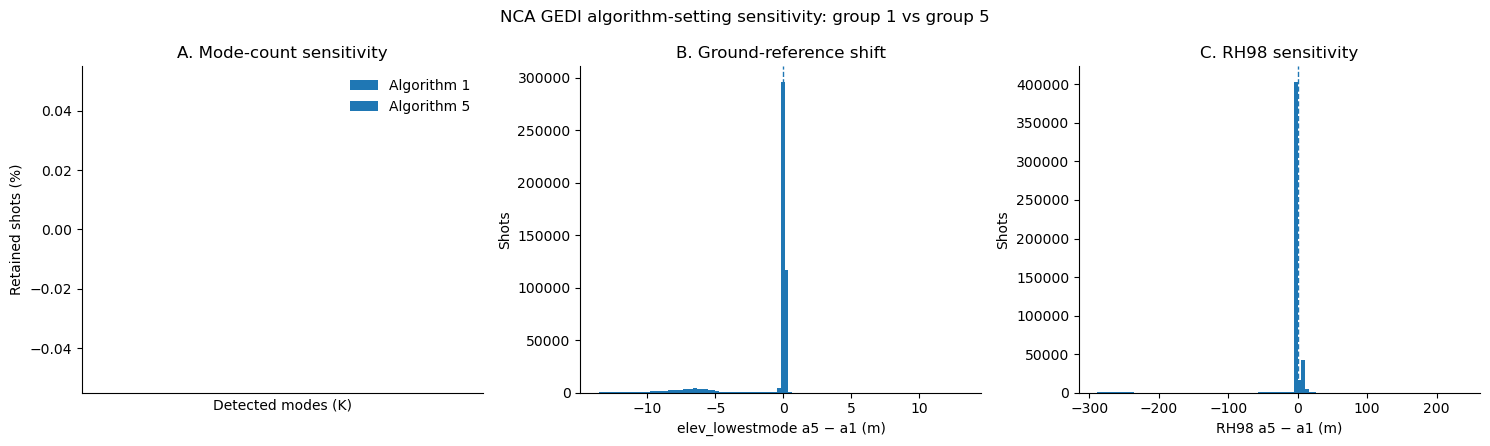

In [6]:

# =============================================================================
# CLEAN COMPARISON FIGURE
# =============================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5),
)

# A: K distributions
d1 = mode_distribution(alg_keep, "num_detectedmodes_a1")
d5 = mode_distribution(alg_keep, "num_detectedmodes_a5")

ks = sorted(set(d1.index) | set(d5.index))
x = np.arange(len(ks))
w = 0.38

y1 = np.array([d1.loc[k, "percent"] if k in d1.index else 0 for k in ks])
y5 = np.array([d5.loc[k, "percent"] if k in d5.index else 0 for k in ks])

axes[0].bar(x - w/2, y1, width=w, label="Algorithm 1")
axes[0].bar(x + w/2, y5, width=w, label="Algorithm 5")
axes[0].set_xticks(x, [str(k) for k in ks])
axes[0].set_xlabel("Detected modes (K)")
axes[0].set_ylabel("Retained shots (%)")
axes[0].set_title("A. Mode-count sensitivity")
axes[0].legend(frameon=False)

# B: ground shift
z = alg_keep["delta_ground_a5_minus_a1_m"].replace([np.inf, -np.inf], np.nan).dropna()
if len(z):
    lim = max(1, np.nanquantile(np.abs(z), 0.995))
    axes[1].hist(z[(z >= -lim) & (z <= lim)], bins=100)
    axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].set_xlabel("elev_lowestmode a5 − a1 (m)")
axes[1].set_ylabel("Shots")
axes[1].set_title("B. Ground-reference shift")

# C: RH98 shift
z = alg_keep["delta_rh98_a5_minus_a1_m"].replace([np.inf, -np.inf], np.nan).dropna()
if len(z):
    lim = max(1, np.nanquantile(np.abs(z), 0.995))
    axes[2].hist(z[(z >= -lim) & (z <= lim)], bins=100)
    axes[2].axvline(0, linestyle="--", linewidth=1)
axes[2].set_xlabel("RH98 a5 − a1 (m)")
axes[2].set_ylabel("Shots")
axes[2].set_title("C. RH98 sensitivity")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("NCA GEDI algorithm-setting sensitivity: group 1 vs group 5")
fig.tight_layout()
plt.show()



## 5. Read an L1B waveform and reconstruct its vertical coordinate

For each shot, L1B provides:

- `rxwaveform`
- `rx_sample_start_index`
- `rx_sample_count`
- `geolocation/elevation_bin0`
- `geolocation/elevation_lastbin`

The waveform elevation coordinate is reconstructed by linear interpolation from bin 0 to the last bin across that shot's waveform samples.

For the group-5 plot:

\[
h_j = z_j - z_{\mathrm{lowestmode,a5}}
\]

so `h = 0` is the center of the algorithm-5 lowest detected mode. Positive values are above that reference.

This is a visualization coordinate, not a claim that every detected mode is vegetation.


In [7]:

def l1b_path_for_key(key):
    p = l1b_lookup.get(key)
    if p is None:
        raise KeyError(f"No L1B subset for {key}")
    return p

def read_l1b_vertical_waveform(granule_key, beam, shot_number):
    path = l1b_path_for_key(granule_key)

    with h5py.File(path, "r") as h5:
        g = h5[beam]

        shots = np.asarray(g["shot_number"]).astype(np.int64)
        idx = np.flatnonzero(shots == int(shot_number))

        if len(idx) != 1:
            raise KeyError(
                f"Expected exactly one L1B match for shot {shot_number}; found {len(idx)}"
            )

        i = int(idx[0])

        start = int(np.asarray(g["rx_sample_start_index"])[i]) - 1
        count = int(np.asarray(g["rx_sample_count"])[i])
        stop = start + count

        rx = np.asarray(g["rxwaveform"][start:stop], dtype=float)

        def shot_scalar(candidates):
            for name in candidates:
                try:
                    arr = np.asarray(g[name])
                    return float(arr[i])
                except Exception:
                    pass
            return np.nan

        z0 = shot_scalar([
            "geolocation/elevation_bin0",
            "elevation_bin0",
        ])

        zlast = shot_scalar([
            "geolocation/elevation_lastbin",
            "elevation_lastbin",
        ])

        noise_mean = shot_scalar([
            "noise_mean_corrected",
            "rx_mean",
        ])

    if not np.isfinite(z0) or not np.isfinite(zlast):
        raise ValueError("Missing L1B elevation_bin0/elevation_lastbin.")

    z = np.linspace(z0, zlast, len(rx))

    return {
        "rx": rx,
        "elevation_m": z,
        "elevation_bin0_m": z0,
        "elevation_lastbin_m": zlast,
        "noise_mean": noise_mean,
    }

def a5_row(granule_key, beam, shot_number):
    m = (
        (alg_keep["granule_key"] == granule_key)
        & (alg_keep["beam"] == beam)
        & (alg_keep["shot_number"].astype(np.int64) == int(shot_number))
    )
    x = alg_keep.loc[m]
    if len(x) != 1:
        raise KeyError(f"Expected one algorithm table row; found {len(x)}")
    return x.iloc[0]

print("Vertical waveform helper ready.")


Vertical waveform helper ready.



## 6. Single-shot vertical waveform: DN on x, height on y

Set `SHOT_SELECTOR` manually or leave it as `None` to choose a retained power-beam shot for which algorithm 5 detected at least two modes.

The black curve is the L1B receive waveform after subtracting the stored L1B noise mean when available. The horizontal reference at 0 m is `elev_lowestmode_a5`.


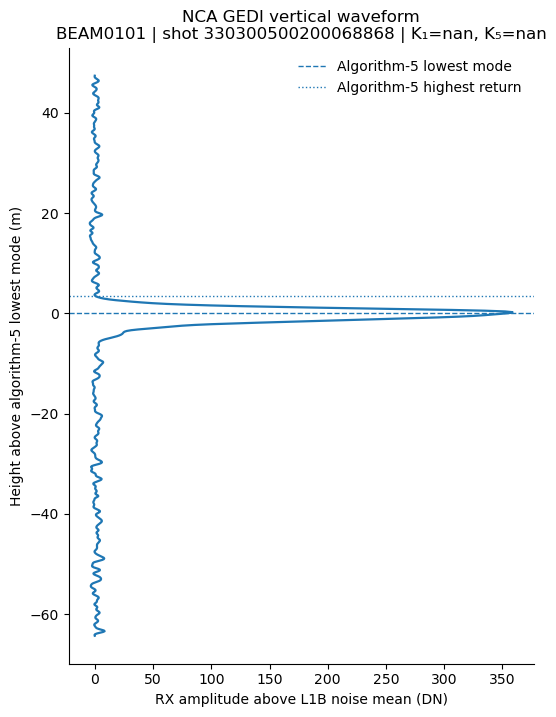

,value
granule_key,O33030_02_T00293_02
beam,BEAM0101
shot_number,330300500200068868
quality_flag,1
degrade_flag,0
sensitivity,0.94543
selected_algorithm,1
num_detectedmodes_a1,NaN
num_detectedmodes_a5,NaN
elev_lowestmode_a1,918.197144


In [8]:

# Set to a dict like:
# SHOT_SELECTOR = {
#     "granule_key": "O23299_03_T01444_02",
#     "beam": "BEAM1000",
#     "shot_number": 232990800300243995,
# }
SHOT_SELECTOR = None

candidate = alg_keep.copy()

candidate = candidate[
    candidate["beam"].isin(POWER_BEAMS)
].copy()

candidate["num_detectedmodes_a5"] = pd.to_numeric(
    candidate["num_detectedmodes_a5"],
    errors="coerce",
)

if SHOT_SELECTOR is None:
    preferred = candidate[
        candidate["num_detectedmodes_a5"].ge(2)
    ]
    if preferred.empty:
        preferred = candidate

    row = preferred.sample(
        n=1,
        random_state=RANDOM_SEED,
    ).iloc[0]
else:
    m = (
        (candidate["granule_key"] == SHOT_SELECTOR["granule_key"])
        & (candidate["beam"] == SHOT_SELECTOR["beam"])
        & (
            candidate["shot_number"].astype(np.int64)
            == int(SHOT_SELECTOR["shot_number"])
        )
    )
    row = candidate.loc[m].iloc[0]

wf = read_l1b_vertical_waveform(
    row["granule_key"],
    row["beam"],
    int(row["shot_number"]),
)

rx = wf["rx"].copy()

if np.isfinite(wf["noise_mean"]):
    rx_plot = rx - wf["noise_mean"]
    xlab = "RX amplitude above L1B noise mean (DN)"
else:
    rx_plot = rx
    xlab = "RX waveform amplitude (DN)"

ground_a5 = float(row["elev_lowestmode_a5"])
height_a5 = wf["elevation_m"] - ground_a5

fig, ax = plt.subplots(figsize=(6, 8))

ax.plot(
    rx_plot,
    height_a5,
    linewidth=1.6,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    label="Algorithm-5 lowest mode",
)

if np.isfinite(row["elev_highestreturn_a5"]):
    ax.axhline(
        row["elev_highestreturn_a5"] - ground_a5,
        linestyle=":",
        linewidth=1,
        label="Algorithm-5 highest return",
    )

ax.set_xlabel(xlab)
ax.set_ylabel("Height above algorithm-5 lowest mode (m)")
ax.set_title(
    f"NCA GEDI vertical waveform\n"
    f"{row['beam']} | shot {int(row['shot_number'])} | "
    f"K₁={row['num_detectedmodes_a1']:.0f}, K₅={row['num_detectedmodes_a5']:.0f}"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.show()

display(
    row[
        [
            "granule_key",
            "beam",
            "shot_number",
            "quality_flag",
            "degrade_flag",
            "sensitivity",
            "selected_algorithm",
            "num_detectedmodes_a1",
            "num_detectedmodes_a5",
            "elev_lowestmode_a1",
            "elev_lowestmode_a5",
            "rh98_a1",
            "rh98_a5",
        ]
    ].to_frame("value")
)



## 7. Overlay algorithm-5 detected mode elevations

If `geolocation/elevs_allmodes_a5` survived in the L2A science source, this cell overlays the actual algorithm-5 detected mode elevations on the vertically registered waveform.

This is the most direct visual test of whether additional group-5 modes correspond to plausible shoulders/returns or weak noise detections.


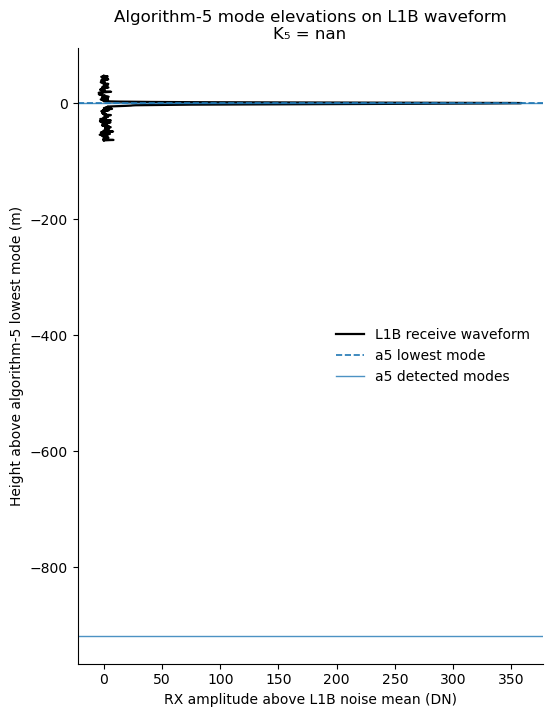

Algorithm-5 mode elevations relative to a5 lowest mode (m):
[-918.34686279    0.        ]


In [9]:

def get_a5_mode_elevations(granule_key, beam, shot_number):
    path = l2a_lookup[granule_key]

    with h5py.File(path, "r") as h5:
        g = h5[beam]

        shots = np.asarray(g["shot_number"]).astype(np.int64)
        idx = np.flatnonzero(shots == int(shot_number))

        if len(idx) != 1:
            raise KeyError(
                f"Expected one L2A shot match; found {len(idx)}"
            )

        i = int(idx[0])

        arr = get_dataset(
            g,
            [
                "geolocation/elevs_allmodes_a5",
                "elevs_allmodes_a5",
            ],
        )

        if arr is None:
            return np.array([])

        vals = np.asarray(arr[i], dtype=float).ravel()

        vals = vals[
            np.isfinite(vals)
            & (vals > -1000)
            & (vals < 25000)
        ]

        # Keep unique elevations only.
        vals = np.unique(vals)

        return vals

mode_elev = get_a5_mode_elevations(
    row["granule_key"],
    row["beam"],
    int(row["shot_number"]),
)

fig, ax = plt.subplots(figsize=(6, 8))

ax.plot(
    rx_plot,
    height_a5,
    color="black",
    linewidth=1.6,
    label="L1B receive waveform",
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2,
    label="a5 lowest mode",
)

for j, zmode in enumerate(mode_elev):
    hmode = zmode - ground_a5
    ax.axhline(
        hmode,
        linewidth=1,
        alpha=0.8,
        label="a5 detected modes" if j == 0 else None,
    )

ax.set_xlabel(xlab)
ax.set_ylabel("Height above algorithm-5 lowest mode (m)")
ax.set_title(
    f"Algorithm-5 mode elevations on L1B waveform\n"
    f"K₅ = {row['num_detectedmodes_a5']:.0f}"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.show()

print("Algorithm-5 mode elevations relative to a5 lowest mode (m):")
print(np.sort(mode_elev - ground_a5))



## 8. Representative vertical waveforms by algorithm-5 detected mode count

For each available \(K_5\), select one retained power-beam shot whose algorithm-5 RH98 is closest to the median RH98 of that \(K_5\) class.

This is a morphology display, not a population estimate. High-\(K\) classes may contain very few shots.


In [10]:

representatives = []

work = alg_keep[
    alg_keep["beam"].isin(POWER_BEAMS)
].copy()

work["K5"] = pd.to_numeric(
    work["num_detectedmodes_a5"],
    errors="coerce",
)

for k in sorted(work["K5"].dropna().astype(int).unique()):
    sub = work[work["K5"] == k].copy()

    if sub.empty:
        continue

    rh = pd.to_numeric(sub["rh98_a5"], errors="coerce")
    med = rh.median()

    if np.isfinite(med):
        sub["_dist"] = np.abs(rh - med)
        rep = sub.sort_values("_dist").iloc[0]
    else:
        rep = sub.iloc[0]

    representatives.append(rep)

rep_df = pd.DataFrame(representatives).reset_index(drop=True)

display(
    rep_df[
        [
            "K5",
            "granule_key",
            "beam",
            "shot_number",
            "rh98_a5",
            "num_detectedmodes_a1",
            "selected_algorithm",
        ]
    ]
)


KeyError: "None of [Index(['K5', 'granule_key', 'beam', 'shot_number', 'rh98_a5',\n       'num_detectedmodes_a1', 'selected_algorithm'],\n      dtype='str')] are in the [columns]"

In [ ]:

# Plot up to the first 6 available K5 classes.
plot_reps = rep_df.head(6).copy()

n = len(plot_reps)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 4.8 * nrows),
    squeeze=False,
)

axes = axes.ravel()

for ax, (_, r) in zip(axes, plot_reps.iterrows()):
    wf_i = read_l1b_vertical_waveform(
        r["granule_key"],
        r["beam"],
        int(r["shot_number"]),
    )

    rx_i = wf_i["rx"].astype(float)

    if np.isfinite(wf_i["noise_mean"]):
        rx_i = rx_i - wf_i["noise_mean"]

    g5 = float(r["elev_lowestmode_a5"])
    h_i = wf_i["elevation_m"] - g5

    ax.plot(
        rx_i,
        h_i,
        color="black",
        linewidth=1.4,
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=0.8,
    )

    modes_i = get_a5_mode_elevations(
        r["granule_key"],
        r["beam"],
        int(r["shot_number"]),
    )

    for zmode in modes_i:
        ax.axhline(
            zmode - g5,
            linewidth=0.8,
            alpha=0.6,
        )

    ax.set_title(
        f"K₅ = {int(r['K5'])} | "
        f"K₁ = {r['num_detectedmodes_a1']:.0f} | "
        f"RH98₅ = {r['rh98_a5']:.2f} m\n"
        f"n(K₅) = {(work['K5'] == r['K5']).sum():,}"
    )

    ax.set_xlabel("RX amplitude above noise mean (DN)")
    ax.set_ylabel("Height above a5 lowest mode (m)")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle(
    "Representative NCA GEDI vertical waveforms by algorithm-5 mode count",
    fontsize=15,
)

fig.tight_layout()
plt.show()



## 9. Shots where algorithm 5 differs most from algorithm 1

These are the most useful cases for manual validation.

The table prioritizes:
- increased mode count under algorithm 5,
- large algorithm-5 vs algorithm-1 ground-reference shifts,
- large RH98 changes.

Inspect these before deciding whether algorithm 5 should replace, supplement, or only sensitivity-test the default/selected GEDI solution.


In [ ]:

review = alg_keep.copy()

review["delta_K"] = (
    pd.to_numeric(review["num_detectedmodes_a5"], errors="coerce")
    - pd.to_numeric(review["num_detectedmodes_a1"], errors="coerce")
)

review["abs_ground_shift_m"] = np.abs(
    review["delta_ground_a5_minus_a1_m"]
)

review["abs_rh98_shift_m"] = np.abs(
    review["delta_rh98_a5_minus_a1_m"]
)

cols = [
    "granule_key",
    "beam",
    "shot_number",
    "sensitivity",
    "selected_algorithm",
    "num_detectedmodes_a1",
    "num_detectedmodes_a5",
    "delta_K",
    "elev_lowestmode_a1",
    "elev_lowestmode_a5",
    "delta_ground_a5_minus_a1_m",
    "rh98_a1",
    "rh98_a5",
    "delta_rh98_a5_minus_a1_m",
]

print("Largest increases in detected modes:")
display(
    review.sort_values(
        ["delta_K", "abs_ground_shift_m"],
        ascending=[False, False],
    )[cols].head(30)
)

print("\nLargest algorithm-specific ground-reference changes:")
display(
    review.nlargest(
        30,
        "abs_ground_shift_m",
    )[cols]
)



## Interpretation checkpoints

Before adopting algorithm 5 for the FINESST analysis, answer these explicitly:

1. **Mode recovery:** Does \(K_5>K_1\) correspond to visible, coherent waveform shoulders or returns?
2. **Noise admission:** How often does group 5 place a lowest mode in low-amplitude/noise-like trailing structure?
3. **Ground stability:** What is the distribution of `elev_lowestmode_a5 - elev_lowestmode_a1`?
4. **RH sensitivity:** Are RH changes physically plausible given the raw vertical waveform?
5. **Terrain dependence:** Do algorithm differences increase with slope/local relief?
6. **Ecological interpretation:** Do not interpret extra modes as vegetation layers without independent evidence.
7. **FINESST consistency:** Group 5 can be used as a documented processing sensitivity/alternative algorithm setting within the proposed constrained waveform framework; the choice should be empirically justified rather than assumed.

A sensible decision rule is to retain both algorithm-1/default and algorithm-5 outputs through validation, then choose the primary representation only after inspecting false-low-mode behavior and terrain dependence.
